# The Bias-Variance Tradeoff

Why does a model do great on training data and badly on new data?
And why does making a model *more* powerful sometimes make it *worse*?

This is the framework that answers both — and it's probably the most directly
useful thing in this pillar.

## Your model's error comes from two different places

**Bias — the model is too simple.**
It can't represent the real pattern, so it's wrong in a consistent, systematic way.
Fit a straight line through curved data and it will always miss — it literally cannot bend.
This is **underfitting**.

**Variance — the model is too complex.**
It's so flexible that it memorises the *noise* in the training data, not just the signal.
Train it on slightly different data and you get a noticeably different model.
This is **overfitting**.

The difference in one line:
**bias is being consistently wrong; variance is being inconsistently right.**

### The archery picture

- **high bias, low variance** — arrows tightly grouped but off to the left. Reliably wrong.
- **low bias, high variance** — arrows scattered everywhere. Average is the bullseye,
  but no single shot is trustworthy.
- **low both** — tight group on the bullseye. What we want.

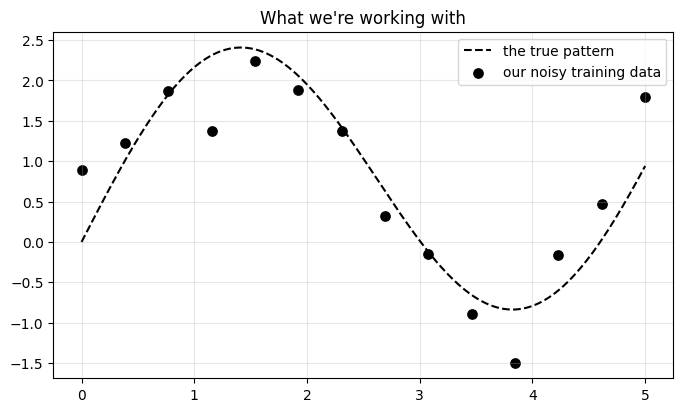

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(3)

# the real pattern we're trying to learn (a gentle curve)
def true_pattern(x):
    return np.sin(x * 1.2) * 2 + x * 0.3

# our training data: a few points from that pattern, plus noise
x_train = np.linspace(0, 5, 14)
y_train = true_pattern(x_train) + np.random.randn(14) * 0.5

# a fine grid just for drawing smooth curves
x_smooth = np.linspace(0, 5, 300)

plt.figure(figsize=(8, 4.5))
plt.plot(x_smooth, true_pattern(x_smooth), "k--", label="the true pattern")
plt.scatter(x_train, y_train, color="black", s=45, label="our noisy training data")
plt.legend()
plt.title("What we're working with")
plt.grid(alpha=0.3)
plt.show()

## Three models on the same data

We'll fit polynomials of different complexity. Degree 1 is a straight line,
degree 13 can wiggle a lot.

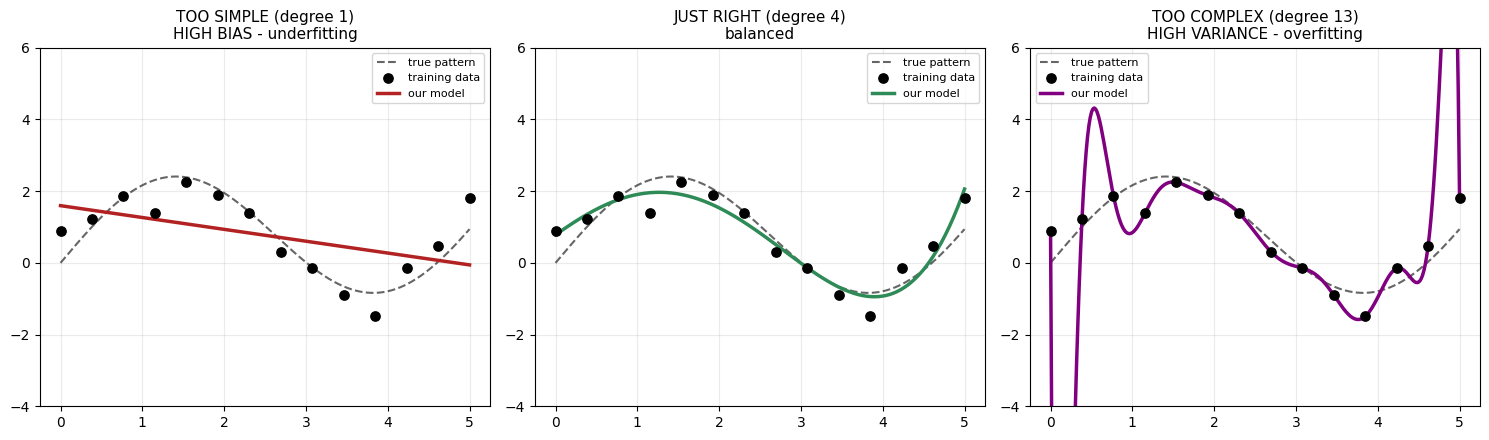

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

degrees = [1, 4, 13]
titles = ["TOO SIMPLE (degree 1)\nHIGH BIAS - underfitting",
          "JUST RIGHT (degree 4)\nbalanced",
          "TOO COMPLEX (degree 13)\nHIGH VARIANCE - overfitting"]
colours = ["firebrick", "seagreen", "purple"]

for i in range(3):
    ax = axes[i]
    # fit a polynomial of this degree to our training data
    coefficients = np.polyfit(x_train, y_train, degrees[i])
    fitted_curve = np.polyval(coefficients, x_smooth)

    ax.plot(x_smooth, true_pattern(x_smooth), "k--", alpha=0.6, label="true pattern")
    ax.scatter(x_train, y_train, color="black", s=45, zorder=5, label="training data")
    ax.plot(x_smooth, fitted_curve, color=colours[i], linewidth=2.5, label="our model")
    ax.set_ylim(-4, 6)
    ax.set_title(titles[i], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Look at what each one is doing:

- **Degree 1** can't bend, so it misses the curve completely. Notice: more data
  wouldn't help at all — it's structurally incapable of curving.
- **Degree 4** follows the true pattern without chasing individual dots.
- **Degree 13** twists violently to pass through nearly every point, *including the
  noise*. Between the dots it swings off to places the true pattern never goes.
  It fits the training dots beautifully and the actual pattern terribly.

## Now the key picture: what happens as complexity increases?

We'll fit every degree from 1 to 12, and track two things:
- how well it does on the **training** data (data it has seen)
- how well it does on **test** data (data it hasn't seen)

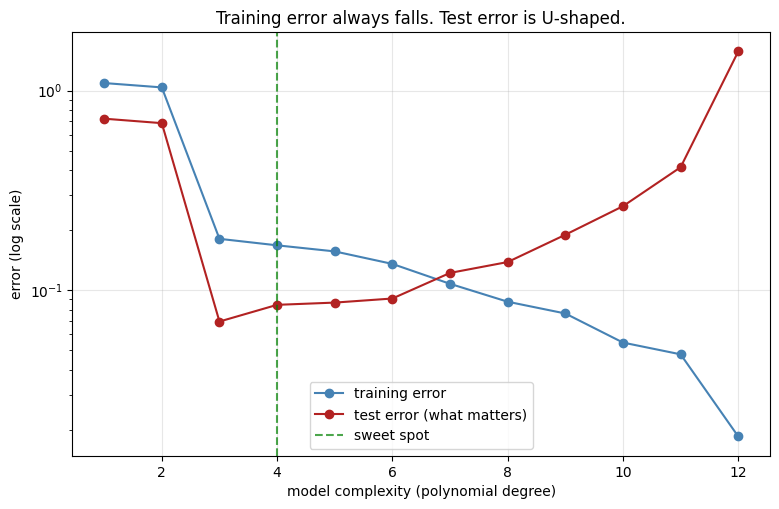

In [3]:
# test data: points from the true pattern that the model never trains on
x_test = np.linspace(0.2, 4.8, 60)
y_test = true_pattern(x_test)

def make_training_data(n=14):
    x = np.linspace(0, 5, n)
    y = true_pattern(x) + np.random.randn(n) * 0.5
    return x, y

training_errors = []
test_errors = []

for degree in range(1, 13):
    train_scores = []
    test_scores = []

    # repeat 60 times with fresh random data, then average
    for trial in range(60):
        xt, yt = make_training_data()
        coefficients = np.polyfit(xt, yt, degree)

        train_scores.append(np.mean((np.polyval(coefficients, xt) - yt) ** 2))
        test_scores.append(np.mean((np.polyval(coefficients, x_test) - y_test) ** 2))

    training_errors.append(np.mean(train_scores))
    test_errors.append(np.mean(test_scores))

plt.figure(figsize=(9, 5.5))
plt.plot(range(1, 13), training_errors, "o-", color="steelblue", label="training error")
plt.plot(range(1, 13), test_errors, "o-", color="firebrick", label="test error (what matters)")
plt.yscale("log")
plt.axvline(4, color="green", linestyle="--", alpha=0.7, label="sweet spot")
plt.xlabel("model complexity (polynomial degree)")
plt.ylabel("error (log scale)")
plt.title("Training error always falls. Test error is U-shaped.")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This is the picture to remember.

- **Training error (blue) always falls.** A more flexible model can always fit the
  data it's already seen a bit better. **So training error alone tells you nothing.**
- **Test error (red) is U-shaped.** It drops as you escape underfitting, bottoms out,
  then climbs again as overfitting kicks in.

**The gap between the two curves is your variance.** Small gap = stable model.
Growing gap = it's memorising.

Your goal is the bottom of the **red** curve, not the blue one.

## Diagnosing your own model

Compare training performance against validation/test performance:

| training | test | diagnosis |
|---|---|---|
| bad | bad | **high bias** (underfitting) |
| great | bad | **high variance** (overfitting) |
| good | good | you're done |

Two questions to ask:
1. **Is training performance good?** No -> high bias (it can't even learn the data it saw)
2. **Is there a big gap between training and test?** Yes -> high variance (it learned noise)

(You can have both at once — bad training score *and* a big gap.)

In [4]:
np.random.seed(7)

def average_test_error(degree, n_points, trials=40):
    errors = []
    for t in range(trials):
        x_train = np.linspace(0, 5, n_points)
        y_train = true_pattern(x_train) + np.random.randn(n_points) * 0.5
        coefficients = np.polyfit(x_train, y_train, degree)
        predictions = np.polyval(coefficients, x_test)
        errors.append(np.mean((predictions - y_test) ** 2))
    return sum(errors) / len(errors)

print("SIMPLE model (degree 1) - suffers from HIGH BIAS")
for n in [15, 50, 200, 1000]:
    print("   training points:", n, "-> test error:", round(average_test_error(1, n), 4))

print()
print("COMPLEX model (degree 12) - suffers from HIGH VARIANCE")
for n in [15, 50, 200, 1000]:
    print("   training points:", n, "-> test error:", round(average_test_error(12, n), 4))

SIMPLE model (degree 1) - suffers from HIGH BIAS
   training points: 15 -> test error: 0.6942
   training points: 50 -> test error: 0.6054
   training points: 200 -> test error: 0.5734
   training points: 1000 -> test error: 0.5655

COMPLEX model (degree 12) - suffers from HIGH VARIANCE
   training points: 15 -> test error: 0.6289
   training points: 50 -> test error: 0.0537
   training points: 200 -> test error: 0.0135
   training points: 1000 -> test error: 0.0028


Look at what happened with 66x more data:

- the **high bias** model went from 0.69 to 0.57 — it barely moved and then plateaued
- the **high variance** model went from 0.63 to 0.003 — a 200x improvement

**More data cures variance. It does nothing for bias.**

This is genuinely the most practically useful line in the topic. Collecting more
data is expensive — if your problem is bias, you'd be wasting time and money.
Diagnose first.

## One honest modern caveat

The classic U-curve came from classical ML (regression, small models). Deep learning
partly breaks it.

Very large neural networks have enough parameters to memorise their entire training
set, so by classical theory they should overfit catastrophically — yet they often
generalise well. Push complexity far past the overfitting peak and test error can
start **falling again**. This is called **double descent**, and why it happens is
still an active research question.

So don't treat "more parameters = worse" as a law for modern deep learning.

**But the diagnosis still works:** a big train/test gap still means variance, a bad
training score still means bias, and the fixes still apply.